In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/data_centre_sensor_data.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (80640, 14)
             Timestamp Server_ID Rack_ID  CPU_pct  Memory_pct  Disk_pct  \
0  2026-08-01 00:00:00    SRV001  RACK01    43.93       53.81     44.97   
1  2026-08-01 00:05:00    SRV001  RACK01    44.87       52.42     45.75   
2  2026-08-01 00:10:00    SRV001  RACK01    47.05       55.08     44.17   
3  2026-08-01 00:15:00    SRV001  RACK01    49.73       54.99     44.02   
4  2026-08-01 00:20:00    SRV001  RACK01    40.76       55.92     46.55   

   Temperature_C  Network_MBps  Fan_RPM  Power_kW  Error_Count  Anomaly_Flag  \
0          29.40        379.98   1979.1      3.90            0             0   
1          28.87        378.61   1979.1      3.90            0             0   
2          29.33        405.30   2005.3      3.99            0             0   
3          30.16        395.84   2087.9      3.99            0             0   
4          28.59        420.90   1840.1      3.85            0             0   

   Failure_Within_24h Incident_Type  
0  

In [3]:
features = [
    "CPU_pct",
    "Memory_pct",
    "Disk_pct",
    "Temperature_C",
    "Network_MBps",
    "Fan_RPM",
    "Power_kW",
    "Error_Count",
    "Anomaly_Flag"
]

X = df[features]
y = df["Failure_Within_24h"]

print("Features:")
print(features)

print("\nTarget distribution:")
print(y.value_counts())

Features:
['CPU_pct', 'Memory_pct', 'Disk_pct', 'Temperature_C', 'Network_MBps', 'Fan_RPM', 'Power_kW', 'Error_Count', 'Anomaly_Flag']

Target distribution:
0    70194
1    10446
Name: Failure_Within_24h, dtype: int64


In [4]:
# Convert timestamp to datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Sort chronologically
df = df.sort_values("Timestamp").reset_index(drop=True)

# Re-create X and y after sorting
X = df[features]
y = df["Failure_Within_24h"]

# 80% training, 20% testing
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training rows: 64512
Testing rows: 16128

Training target distribution:
0    55772
1     8740
Name: Failure_Within_24h, dtype: int64

Testing target distribution:
0    14422
1     1706
Name: Failure_Within_24h, dtype: int64


In [5]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [6]:
# Predict failure class
y_pred = model.predict(X_test)

# Predict probability of failure
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 16128


In [7]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", round(accuracy, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8164
ROC-AUC: 0.6267

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90     14422
           1       0.16      0.17      0.16      1706

    accuracy                           0.82     16128
   macro avg       0.53      0.53      0.53     16128
weighted avg       0.82      0.82      0.82     16128



Confusion Matrix:
[[12885  1537]
 [ 1424   282]]


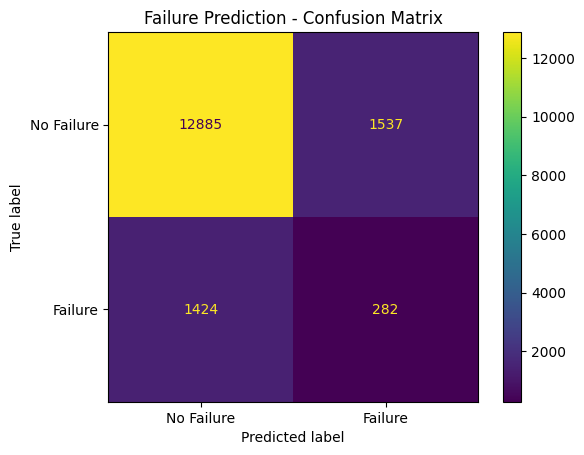

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Failure", "Failure"]
).plot()

plt.title("Failure Prediction - Confusion Matrix")
plt.show()

In [9]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("Feature Importance:")
print(importance)

Feature Importance:
Disk_pct         0.353290
Power_kW         0.168406
Temperature_C    0.154146
Memory_pct       0.118887
CPU_pct          0.086823
Fan_RPM          0.053955
Network_MBps     0.043271
Anomaly_Flag     0.014688
Error_Count      0.006535
dtype: float64


In [10]:
# Make a working copy
df_ml = df.copy()

# Make sure data is ordered correctly
df_ml["Timestamp"] = pd.to_datetime(df_ml["Timestamp"])
df_ml = df_ml.sort_values(["Server_ID", "Timestamp"]).reset_index(drop=True)

# Previous observation for each server
df_ml["Temperature_change"] = (
    df_ml.groupby("Server_ID")["Temperature_C"].diff()
)

df_ml["CPU_change"] = (
    df_ml.groupby("Server_ID")["CPU_pct"].diff()
)

df_ml["Disk_change"] = (
    df_ml.groupby("Server_ID")["Disk_pct"].diff()
)

df_ml["Power_change"] = (
    df_ml.groupby("Server_ID")["Power_kW"].diff()
)

print("Basic time-based features created!")

Basic time-based features created!


In [11]:
# Create rolling features using only previous observations
sensor_columns = [
    "CPU_pct",
    "Memory_pct",
    "Disk_pct",
    "Temperature_C",
    "Power_kW",
    "Error_Count"
]

for col in sensor_columns:
    df_ml[f"{col}_mean_1h"] = (
        df_ml.groupby("Server_ID")[col]
        .transform(lambda x: x.shift(1).rolling(12, min_periods=1).mean())
    )

    df_ml[f"{col}_mean_6h"] = (
        df_ml.groupby("Server_ID")[col]
        .transform(lambda x: x.shift(1).rolling(72, min_periods=1).mean())
    )

print("Rolling features created!")

Rolling features created!


In [12]:
df_ml["Hour"] = df_ml["Timestamp"].dt.hour
df_ml["DayOfWeek"] = df_ml["Timestamp"].dt.dayofweek

print("Time features created!")

Time features created!


In [13]:
print("Original columns:", len(df.columns))
print("New columns:", len(df_ml.columns))

print("\nNew columns:")
print(df_ml.columns.tolist())

Original columns: 14
New columns: 32

New columns:
['Timestamp', 'Server_ID', 'Rack_ID', 'CPU_pct', 'Memory_pct', 'Disk_pct', 'Temperature_C', 'Network_MBps', 'Fan_RPM', 'Power_kW', 'Error_Count', 'Anomaly_Flag', 'Failure_Within_24h', 'Incident_Type', 'Temperature_change', 'CPU_change', 'Disk_change', 'Power_change', 'CPU_pct_mean_1h', 'CPU_pct_mean_6h', 'Memory_pct_mean_1h', 'Memory_pct_mean_6h', 'Disk_pct_mean_1h', 'Disk_pct_mean_6h', 'Temperature_C_mean_1h', 'Temperature_C_mean_6h', 'Power_kW_mean_1h', 'Power_kW_mean_6h', 'Error_Count_mean_1h', 'Error_Count_mean_6h', 'Hour', 'DayOfWeek']


In [14]:
improved_features = [
    "CPU_pct",
    "Memory_pct",
    "Disk_pct",
    "Temperature_C",
    "Network_MBps",
    "Fan_RPM",
    "Power_kW",
    "Error_Count",
    "Anomaly_Flag",

    "Temperature_change",
    "CPU_change",
    "Disk_change",
    "Power_change",

    "CPU_pct_mean_1h",
    "CPU_pct_mean_6h",
    "Memory_pct_mean_1h",
    "Memory_pct_mean_6h",
    "Disk_pct_mean_1h",
    "Disk_pct_mean_6h",
    "Temperature_C_mean_1h",
    "Temperature_C_mean_6h",
    "Power_kW_mean_1h",
    "Power_kW_mean_6h",
    "Error_Count_mean_1h",
    "Error_Count_mean_6h",

    "Hour",
    "DayOfWeek"
]

X_new = df_ml[improved_features]
y_new = df_ml["Failure_Within_24h"]

print("Number of features:", len(improved_features))
print("X shape:", X_new.shape)
print("y shape:", y_new.shape)

Number of features: 27
X shape: (80640, 27)
y shape: (80640,)


In [15]:
missing = X_new.isnull().sum()

print("Total missing values:", missing.sum())

print("\nColumns with missing values:")
print(missing[missing > 0])

Total missing values: 320

Columns with missing values:
Temperature_change       20
CPU_change               20
Disk_change              20
Power_change             20
CPU_pct_mean_1h          20
CPU_pct_mean_6h          20
Memory_pct_mean_1h       20
Memory_pct_mean_6h       20
Disk_pct_mean_1h         20
Disk_pct_mean_6h         20
Temperature_C_mean_1h    20
Temperature_C_mean_6h    20
Power_kW_mean_1h         20
Power_kW_mean_6h         20
Error_Count_mean_1h      20
Error_Count_mean_6h      20
dtype: int64


In [16]:
# Check missing values
print("Missing values before cleaning:")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

# Remove rows where rolling/change features cannot be calculated
df_model_clean = df_model.dropna().copy()

print("\nRows before:", len(df_model))
print("Rows after:", len(df_model_clean))

print("\nMissing values after cleaning:",
    df_model_clean.isnull().sum().sum())

Missing values before cleaning:


NameError: name 'df_model' is not defined

In [ ]:
# Check missing values
print("Missing values before cleaning:")
print(X_new.isnull().sum()[X_new.isnull().sum() > 0])

# Remove rows with missing engineered features
valid_rows = X_new.notnull().all(axis=1)

X_clean = X_new.loc[valid_rows].copy()
y_clean = y_new.loc[valid_rows].copy()

print("\nRows before:", len(X_new))
print("Rows after:", len(X_clean))

print("\nMissing values after cleaning:", X_clean.isnull().sum().sum())

Missing values before cleaning:
Temperature_change       20
CPU_change               20
Disk_change              20
Power_change             20
CPU_pct_mean_1h          20
CPU_pct_mean_6h          20
Memory_pct_mean_1h       20
Memory_pct_mean_6h       20
Disk_pct_mean_1h         20
Disk_pct_mean_6h         20
Temperature_C_mean_1h    20
Temperature_C_mean_6h    20
Power_kW_mean_1h         20
Power_kW_mean_6h         20
Error_Count_mean_1h      20
Error_Count_mean_6h      20
dtype: int64

Rows before: 80640
Rows after: 80620

Missing values after cleaning: 0


In [ ]:
from sklearn.model_selection import train_test_split

# Keep chronological order
split_index = int(len(X_clean) * 0.80)

X_train_new = X_clean.iloc[:split_index]
X_test_new = X_clean.iloc[split_index:]

y_train_new = y_clean.iloc[:split_index]
y_test_new = y_clean.iloc[split_index:]

print("Training rows:", len(X_train_new))
print("Testing rows:", len(X_test_new))

print("\nTraining target distribution:")
print(y_train_new.value_counts())

print("\nTesting target distribution:")
print(y_test_new.value_counts())

Training rows: 64496
Testing rows: 16124

Training target distribution:
0    56133
1     8363
Name: Failure_Within_24h, dtype: int64

Testing target distribution:
0    14045
1     2079
Name: Failure_Within_24h, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_new = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model_new.fit(X_train_new, y_train_new)

print("Improved model training completed!")

Improved model training completed!


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_new = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model_new.fit(X_train_new, y_train_new)

print("Improved model training completed!")

Improved model training completed!


In [ ]:
# Make predictions
y_pred_new = model_new.predict(X_test_new)

# Probability of failure
y_prob_new = model_new.predict_proba(X_test_new)[:, 1]

print("Predictions completed!")
print("Number of predictions:", len(y_pred_new))

Predictions completed!
Number of predictions: 16124


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

accuracy_new = accuracy_score(y_test_new, y_pred_new)
roc_auc_new = roc_auc_score(y_test_new, y_prob_new)

print("MODEL 2 - IMPROVED RESULTS")
print("----------------------------")
print("Accuracy:", round(accuracy_new, 4))
print("ROC-AUC:", round(roc_auc_new, 4))

print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_new))

MODEL 2 - IMPROVED RESULTS
----------------------------
Accuracy: 0.8136
ROC-AUC: 0.5573

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90     14045
           1       0.05      0.03      0.03      2079

    accuracy                           0.81     16124
   macro avg       0.46      0.48      0.47     16124
weighted avg       0.76      0.81      0.79     16124



In [ ]:
# Compare sensor averages for failure vs no-failure cases

sensor_features = [
    "CPU_pct",
    "Memory_pct",
    "Disk_pct",
    "Temperature_C",
    "Network_MBps",
    "Fan_RPM",
    "Power_kW",
    "Error_Count",
    "Anomaly_Flag"
]

comparison = df.groupby("Failure_Within_24h")[sensor_features].mean().T

comparison.columns = ["No Failure", "Failure"]

print(comparison.round(2))

               No Failure  Failure
CPU_pct             45.48    45.30
Memory_pct          56.42    56.27
Disk_pct            75.52    69.96
Temperature_C       27.32    27.30
Network_MBps       411.79   413.42
Fan_RPM           2010.20  2010.19
Power_kW             3.85     3.83
Error_Count          0.22     0.16
Anomaly_Flag         0.27     0.21


In [ ]:
# Difference between failure and non-failure averages

comparison["Difference"] = (
    comparison["Failure"] - comparison["No Failure"]
)

print("\nDifference:")
print(comparison["Difference"].sort_values(ascending=False).round(2))


Difference:
Network_MBps     1.63
Fan_RPM         -0.01
Power_kW        -0.01
Temperature_C   -0.02
Error_Count     -0.06
Anomaly_Flag    -0.07
Memory_pct      -0.15
CPU_pct         -0.17
Disk_pct        -5.56
Name: Difference, dtype: float64


In [ ]:
df.groupby("Failure_Within_24h")["Disk_pct"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Failure_Within_24h,,,,,,,,
0,70194.0,75.52,16.74,39.22,61.24,76.56,90.96,99.0
1,10446.0,69.96,17.31,39.80,54.14,69.12,85.71,98.0


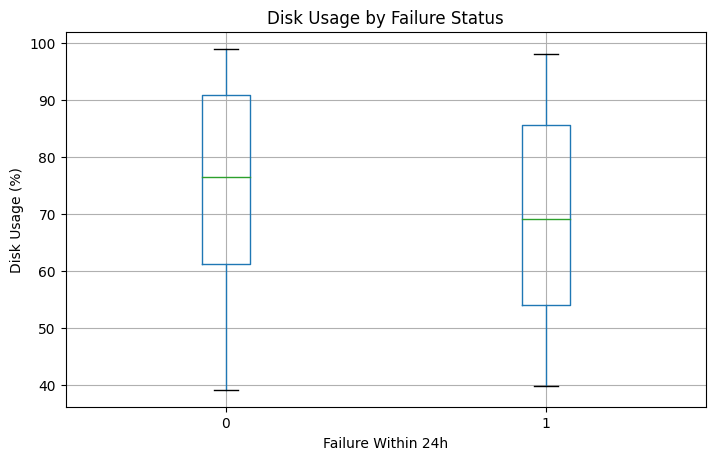

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(
    column="Disk_pct",
    by="Failure_Within_24h",
    figsize=(8, 5)
)

plt.title("Disk Usage by Failure Status")
plt.suptitle("")
plt.xlabel("Failure Within 24h")
plt.ylabel("Disk Usage (%)")
plt.show()

In [17]:
# MODEL 3 - Class Imbalance Handling

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    average_precision_score
)

# Use the cleaned model dataset
X = df_model[features]
y = df_model["Failure_Within_24h"]

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

# Random Forest with class balancing
model3 = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model3.fit(X_train, y_train)

# Predictions
y_pred = model3.predict(X_test)
y_prob = model3.predict_proba(X_test)[:, 1]

# Evaluation
accuracy3 = accuracy_score(y_test, y_pred)
roc_auc3 = roc_auc_score(y_test, y_prob)
pr_auc3 = average_precision_score(y_test, y_prob)

print("\nMODEL 3 - CLASS BALANCED RANDOM FOREST")
print("--------------------------------------")
print(f"Accuracy: {accuracy3:.4f}")
print(f"ROC-AUC: {roc_auc3:.4f}")
print(f"PR-AUC: {pr_auc3:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

NameError: name 'df_model' is not defined

In [ ]:
# Recreate feature-engineered dataframe

df_model = df.copy()

# Create change features
df_model["Temperature_change"] = df_model["Temperature_C"].diff()
df_model["CPU_change"] = df_model["CPU_pct"].diff()
df_model["Disk_change"] = df_model["Disk_pct"].diff()
df_model["Power_change"] = df_model["Power_kW"].diff()

# Rolling features
rolling_cols = [
    "CPU_pct",
    "Memory_pct",
    "Disk_pct",
    "Temperature_C",
    "Power_kW",
    "Error_Count"
]

for col in rolling_cols:
    df_model[f"{col}_mean_1h"] = df_model[col].rolling(12).mean()
    df_model[f"{col}_mean_6h"] = df_model[col].rolling(72).mean()

# Time features
df_model["Hour"] = df_model["Timestamp"].dt.hour
df_model["DayOfWeek"] = df_model["Timestamp"].dt.dayofweek

# Remove rows created by rolling calculations
df_model = df_model.dropna().reset_index(drop=True)

print("df_model recreated successfully!")
print("Rows:", len(df_model))
print("Columns:", len(df_model.columns))

df_model recreated successfully!
Rows: 80569
Columns: 32


In [ ]:
features = [
    "CPU_pct",
    "Memory_pct",
    "Disk_pct",
    "Temperature_C",
    "Network_MBps",
    "Fan_RPM",
    "Power_kW",
    "Error_Count",
    "Anomaly_Flag"
]

print("Features:", features)
print("Target:", "Failure_Within_24h")
print("\nTarget distribution:")
print(df_model["Failure_Within_24h"].value_counts())

Features: ['CPU_pct', 'Memory_pct', 'Disk_pct', 'Temperature_C', 'Network_MBps', 'Fan_RPM', 'Power_kW', 'Error_Count', 'Anomaly_Flag']
Target: Failure_Within_24h

Target distribution:
0    70138
1    10431
Name: Failure_Within_24h, dtype: int64


Confusion Matrix:
[[11873  2155]
 [  626  1460]]


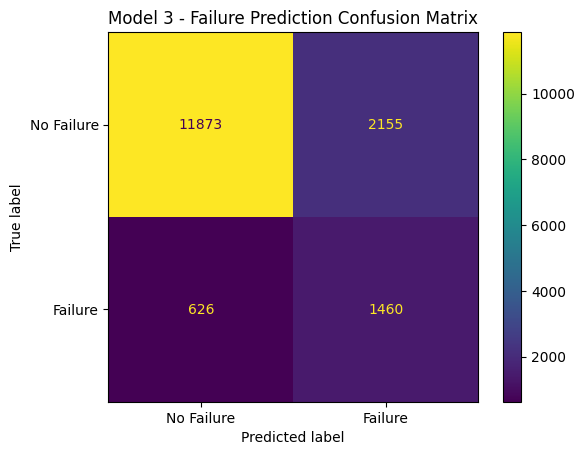

In [ ]:
# MODEL 3 - CONFUSION MATRIX

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm3 = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm3)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm3,
    display_labels=["No Failure", "Failure"]
)

disp.plot()
plt.title("Model 3 - Failure Prediction Confusion Matrix")
plt.show()

Model 3 Feature Importance:
Disk_pct         0.335822
Temperature_C    0.170261
Power_kW         0.161898
Memory_pct       0.124719
CPU_pct          0.084182
Fan_RPM          0.053065
Network_MBps     0.040949
Anomaly_Flag     0.019894
Error_Count      0.009210
dtype: float64


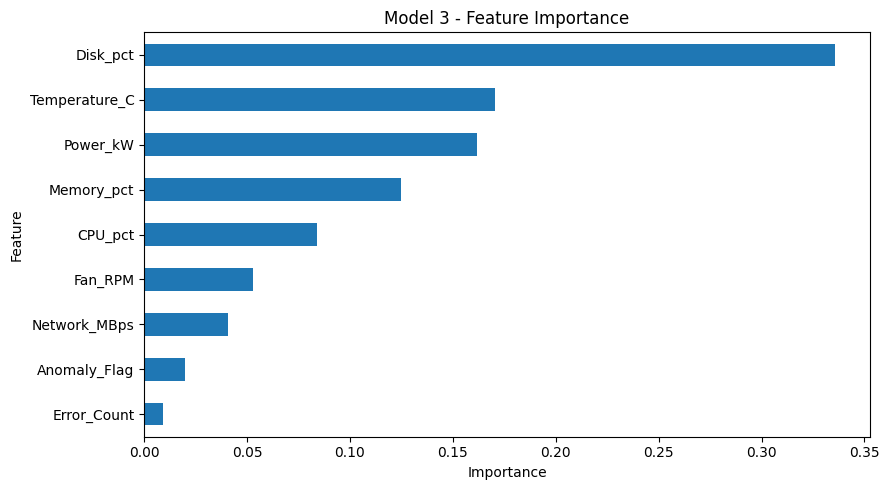

In [ ]:
# MODEL 3 - FEATURE IMPORTANCE

importance3 = pd.Series(
    model3.feature_importances_,
    index=features
).sort_values(ascending=False)

print("Model 3 Feature Importance:")
print(importance3)

plt.figure(figsize=(9, 5))
importance3.sort_values().plot(kind="barh")
plt.title("Model 3 - Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# FAILURE RISK SCORE

risk_scores = model3.predict_proba(X_test)[:, 1]

risk_df = X_test.copy()
risk_df["Actual_Failure"] = y_test.values
risk_df["Failure_Probability"] = risk_scores

# Convert probability to percentage
risk_df["Risk_Score"] = risk_df["Failure_Probability"] * 100

print("Failure risk scores generated successfully!")
print(risk_df[["Failure_Probability", "Risk_Score", "Actual_Failure"]].head(10))

NameError: name 'model3' is not defined

In [ ]:
# Risk categories

def risk_category(score):
    if score >= 70:
        return "Critical"
    elif score >= 40:
        return "High"
    elif score >= 20:
        return "Medium"
    else:
        return "Low"

risk_df["Risk_Level"] = risk_df["Risk_Score"].apply(risk_category)

print("\nRisk Level Distribution:")
print(risk_df["Risk_Level"].value_counts())


Risk Level Distribution:
Medium      5857
Low         4526
High        4509
Critical    1222
Name: Risk_Level, dtype: int64


In [ ]:
# Top highest-risk records

top_risk = risk_df.sort_values(
    "Risk_Score",
    ascending=False
).head(20)

print("TOP 20 HIGH-RISK RECORDS")
print("------------------------")

display(
    top_risk[
        [
            "Disk_pct",
            "Temperature_C",
            "Power_kW",
            "Memory_pct",
            "CPU_pct",
            "Fan_RPM",
            "Error_Count",
            "Risk_Score",
            "Risk_Level",
            "Actual_Failure"
        ]
    ]
)

TOP 20 HIGH-RISK RECORDS
------------------------


,Disk_pct,Temperature_C,Power_kW,Memory_pct,CPU_pct,Fan_RPM,Error_Count,Risk_Score,Risk_Level,Actual_Failure
10764,50.96,29.77,3.92,55.38,45.18,1906.8,0,88.784928,Critical,1
8091,48.05,29.71,4.05,56.73,54.85,2123.3,1,87.375016,Critical,0
3062,45.66,26.50,3.27,67.98,60.13,2306.9,0,87.368942,Critical,1
1796,47.67,29.65,4.02,58.14,47.19,2073.9,0,87.144434,Critical,1
1459,49.04,29.26,3.92,53.89,47.82,1981.9,0,87.121821,Critical,0
5650,50.53,29.28,3.91,54.14,40.63,1859.2,0,87.117603,Critical,0
4882,48.84,29.64,4.04,56.77,52.73,2088.8,0,86.956659,Critical,0
7382,48.12,29.61,3.98,57.52,48.11,2085.3,0,86.866541,Critical,1
10591,50.35,29.59,3.94,54.66,49.21,2046.0,0,86.664260,Critical,1
4051,47.94,27.46,3.20,66.73,59.83,2257.4,0,86.653697,Critical,1


In [ ]:
# INCIDENT / RISK EXPLANATION

def generate_explanation(row):
    reasons = []

    if row["Disk_pct"] >= 90:
        reasons.append(f"high disk utilization ({row['Disk_pct']:.1f}%)")

    if row["Temperature_C"] >= 34:
        reasons.append(f"elevated temperature ({row['Temperature_C']:.1f}°C)")

    if row["Power_kW"] >= 5:
        reasons.append(f"high power consumption ({row['Power_kW']:.2f} kW)")

    if row["CPU_pct"] >= 80:
        reasons.append(f"high CPU utilization ({row['CPU_pct']:.1f}%)")

    if row["Memory_pct"] >= 70:
        reasons.append(f"high memory utilization ({row['Memory_pct']:.1f}%)")

    if row["Error_Count"] >= 5:
        reasons.append(f"elevated error count ({int(row['Error_Count'])})")

    if row["Fan_RPM"] >= 2500:
        reasons.append(f"elevated fan speed ({row['Fan_RPM']:.0f} RPM)")

    if not reasons:
        reasons.append("no single critical sensor threshold detected")

    return "Potential risk driven by " + ", ".join(reasons) + "."

risk_df["AI_Explanation"] = risk_df.apply(
    generate_explanation,
    axis=1
)

print("AI explanations generated successfully!")

display(
    risk_df[
        [
            "Risk_Score",
            "Risk_Level",
            "Disk_pct",
            "Temperature_C",
            "Power_kW",
            "CPU_pct",
            "Memory_pct",
            "Error_Count",
            "AI_Explanation"
        ]
    ].sort_values(
        "Risk_Score",
        ascending=False
    ).head(10)
)

AI explanations generated successfully!


,Risk_Score,Risk_Level,Disk_pct,Temperature_C,Power_kW,CPU_pct,Memory_pct,Error_Count,AI_Explanation
10764,88.784928,Critical,50.96,29.77,3.92,45.18,55.38,0,Potential risk driven by no single critical se...
8091,87.375016,Critical,48.05,29.71,4.05,54.85,56.73,1,Potential risk driven by no single critical se...
3062,87.368942,Critical,45.66,26.50,3.27,60.13,67.98,0,Potential risk driven by no single critical se...
1796,87.144434,Critical,47.67,29.65,4.02,47.19,58.14,0,Potential risk driven by no single critical se...
1459,87.121821,Critical,49.04,29.26,3.92,47.82,53.89,0,Potential risk driven by no single critical se...
5650,87.117603,Critical,50.53,29.28,3.91,40.63,54.14,0,Potential risk driven by no single critical se...
4882,86.956659,Critical,48.84,29.64,4.04,52.73,56.77,0,Potential risk driven by no single critical se...
7382,86.866541,Critical,48.12,29.61,3.98,48.11,57.52,0,Potential risk driven by no single critical se...
10591,86.664260,Critical,50.35,29.59,3.94,49.21,54.66,0,Potential risk driven by no single critical se...
4051,86.653697,Critical,47.94,27.46,3.20,59.83,66.73,0,Potential risk driven by no single critical se...


In [ ]:
# MAINTENANCE RECOMMENDATION

def maintenance_action(row):
    actions = []

    if row["Disk_pct"] >= 90:
        actions.append("inspect disk capacity and storage health")

    if row["Temperature_C"] >= 34:
        actions.append("inspect cooling and airflow")

    if row["Power_kW"] >= 5:
        actions.append("check power consumption and workload")

    if row["CPU_pct"] >= 80:
        actions.append("review CPU workload")

    if row["Memory_pct"] >= 70:
        actions.append("review memory utilization")

    if row["Error_Count"] >= 5:
        actions.append("investigate system errors")

    if row["Fan_RPM"] >= 2500:
        actions.append("inspect cooling fans")

    if not actions:
        return "Continue routine monitoring."

    return "; ".join(actions).capitalize() + "."

risk_df["Maintenance_Action"] = risk_df.apply(
    maintenance_action,
    axis=1
)

display(
    risk_df[
        [
            "Risk_Score",
            "Risk_Level",
            "AI_Explanation",
            "Maintenance_Action"
        ]
    ].sort_values(
        "Risk_Score",
        ascending=False
    ).head(10)
)

,Risk_Score,Risk_Level,AI_Explanation,Maintenance_Action
10764,88.784928,Critical,Potential risk driven by no single critical se...,Continue routine monitoring.
8091,87.375016,Critical,Potential risk driven by no single critical se...,Continue routine monitoring.
3062,87.368942,Critical,Potential risk driven by no single critical se...,Continue routine monitoring.
1796,87.144434,Critical,Potential risk driven by no single critical se...,Continue routine monitoring.
1459,87.121821,Critical,Potential risk driven by no single critical se...,Continue routine monitoring.
5650,87.117603,Critical,Potential risk driven by no single critical se...,Continue routine monitoring.
4882,86.956659,Critical,Potential risk driven by no single critical se...,Continue routine monitoring.
7382,86.866541,Critical,Potential risk driven by no single critical se...,Continue routine monitoring.
10591,86.664260,Critical,Potential risk driven by no single critical se...,Continue routine monitoring.
4051,86.653697,Critical,Potential risk driven by no single critical se...,Continue routine monitoring.


In [ ]:
# AI OPERATIONS MAINTENANCE REPORT

top = risk_df.sort_values(
    "Risk_Score",
    ascending=False
).iloc[0]

report = f"""
DATA CENTRE PREDICTIVE MAINTENANCE REPORT
=========================================

Failure Risk Score : {top['Risk_Score']:.2f}%
Risk Level         : {top['Risk_Level']}

SYSTEM METRICS
-------------
CPU Utilization    : {top['CPU_pct']:.2f}%
Memory Utilization : {top['Memory_pct']:.2f}%
Disk Utilization   : {top['Disk_pct']:.2f}%
Temperature        : {top['Temperature_C']:.2f} °C
Network Traffic    : {top['Network_MBps']:.2f} MBps
Fan Speed          : {top['Fan_RPM']:.0f} RPM
Power Consumption  : {top['Power_kW']:.2f} kW
Error Count        : {top['Error_Count']}

RISK EXPLANATION
----------------
{top['AI_Explanation']}

RECOMMENDED ACTION
------------------
{top['Maintenance_Action']}

PREDICTIVE MAINTENANCE STATUS
------------------------------
The system has identified this record as a {top['Risk_Level'].lower()}-
risk condition. Maintenance personnel should review the highlighted
infrastructure metrics and investigate the recommended areas.
"""

print(report)


DATA CENTRE PREDICTIVE MAINTENANCE REPORT

Failure Risk Score : 88.78%
Risk Level         : Critical

SYSTEM METRICS
-------------
CPU Utilization    : 45.18%
Memory Utilization : 55.38%
Disk Utilization   : 50.96%
Temperature        : 29.77 °C
Network Traffic    : 427.80 MBps
Fan Speed          : 1907 RPM
Power Consumption  : 3.92 kW
Error Count        : 0

RISK EXPLANATION
----------------
Potential risk driven by no single critical sensor threshold detected.

RECOMMENDED ACTION
------------------
Continue routine monitoring.

PREDICTIVE MAINTENANCE STATUS
------------------------------
The system has identified this record as a critical-
risk condition. Maintenance personnel should review the highlighted
infrastructure metrics and investigate the recommended areas.



In [ ]:
print("Server_ID exists:", "Server_ID" in risk_df.columns)
print("Rack_ID exists:", "Rack_ID" in risk_df.columns)
print("Risk rows:", len(risk_df))
print("Columns:")
print(risk_df.columns.tolist())

NameError: name 'risk_df' is not defined

In [ ]:
# SAVE MODEL PREDICTIONS

output_columns = [
    "Risk_Score",
    "Risk_Level",
    "Disk_pct",
    "Temperature_C",
    "Power_kW",
    "Memory_pct",
    "CPU_pct",
    "Fan_RPM",
    "Network_MBps",
    "Error_Count",
    "Actual_Failure",
    "AI_Explanation",
    "Maintenance_Action"
]

risk_output = risk_df[output_columns].copy()

risk_output.to_csv(
    "data/model3_risk_predictions.csv",
    index=False
)

print("Risk predictions saved successfully!")
print("File: data/model3_risk_predictions.csv")
print("Rows:", len(risk_output))

NameError: name 'risk_df' is not defined

In [ ]:
import os

# Create the data folder if it doesn't exist
os.makedirs("data", exist_ok=True)

print("Data folder ready!")
print("Current working directory:", os.getcwd())

Data folder ready!
Current working directory: c:\Users\mahan\OneDrive\Desktop\DataCentre_Predictive_Maintenance_AI_Starter\DataCentre_Predictive_Maintenance_AI\notebooks


In [ ]:
risk_output.to_csv(
    "data/model3_risk_predictions.csv",
    index=False
)

print("Risk predictions saved successfully!")
print("File: data/model3_risk_predictions.csv")
print("Rows:", len(risk_output))

NameError: name 'risk_output' is not defined

In [ ]:
import os

file_path = "data/model3_risk_predictions.csv"

print("File exists:", os.path.exists(file_path))

if os.path.exists(file_path):
    print("File size:", round(os.path.getsize(file_path) / 1024, 2), "KB")

File exists: True
File size: 2696.45 KB


In [ ]:
import os

os.makedirs("data", exist_ok=True)

print("Working directory:", os.getcwd())
print("Data folder exists:", os.path.exists("data"))

Working directory: c:\Users\mahan\OneDrive\Desktop\DataCentre_Predictive_Maintenance_AI_Starter\DataCentre_Predictive_Maintenance_AI\notebooks
Data folder exists: True


In [18]:
import pandas as pd
import numpy as np

# Load the original dataset
df = pd.read_csv("../data/raw/data_centre_sensor_data.csv")

df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Sort by server and time
df = df.sort_values(["Server_ID", "Timestamp"]).reset_index(drop=True)

# Create time/change features
df["Temperature_change"] = df.groupby("Server_ID")["Temperature_C"].diff()
df["CPU_change"] = df.groupby("Server_ID")["CPU_pct"].diff()
df["Disk_change"] = df.groupby("Server_ID")["Disk_pct"].diff()
df["Power_change"] = df.groupby("Server_ID")["Power_kW"].diff()

# Rolling features
for col in [
    "CPU_pct",
    "Memory_pct",
    "Disk_pct",
    "Temperature_C",
    "Power_kW",
    "Error_Count"
]:
    df[f"{col}_mean_1h"] = (
        df.groupby("Server_ID")[col]
        .transform(lambda x: x.rolling(12, min_periods=1).mean())
    )

    df[f"{col}_mean_6h"] = (
        df.groupby("Server_ID")[col]
        .transform(lambda x: x.rolling(72, min_periods=1).mean())
    )

# Time features
df["Hour"] = df["Timestamp"].dt.hour
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

# Remove rows where change features cannot be calculated
df_model = df.dropna().copy()

print("df_model created successfully!")
print("Rows:", len(df_model))
print("Columns:", len(df_model.columns))
print("Server_ID available:", "Server_ID" in df_model.columns)

df_model created successfully!
Rows: 80620
Columns: 32
Server_ID available: True


In [19]:
features = [
    "CPU_pct",
    "Memory_pct",
    "Disk_pct",
    "Temperature_C",
    "Network_MBps",
    "Fan_RPM",
    "Power_kW",
    "Error_Count",
    "Anomaly_Flag"
]

X = df_model[features]
y = df_model["Failure_Within_24h"]

print("Features:", features)
print("Target distribution:")
print(y.value_counts())

Features: ['CPU_pct', 'Memory_pct', 'Disk_pct', 'Temperature_C', 'Network_MBps', 'Fan_RPM', 'Power_kW', 'Error_Count', 'Anomaly_Flag']
Target distribution:
0    70178
1    10442
Name: Failure_Within_24h, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 64496
Testing rows: 16124


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 64496
Testing rows: 16124


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

# Model 3: Class-balanced Random Forest
model3 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model3.fit(X_train, y_train)

# Predictions
y_pred = model3.predict(X_test)
y_prob = model3.predict_proba(X_test)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("MODEL 3 - CLASS BALANCED RANDOM FOREST")
print("--------------------------------------")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

MODEL 3 - CLASS BALANCED RANDOM FOREST
--------------------------------------
Accuracy: 0.8815
ROC-AUC: 0.8810
PR-AUC: 0.5088

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.94     14036
           1       0.65      0.19      0.29      2088

    accuracy                           0.88     16124
   macro avg       0.77      0.59      0.61     16124
weighted avg       0.86      0.88      0.85     16124



In [23]:
# Create risk predictions while preserving server/rack information

test_indices = X_test.index

risk_df = df_model.loc[test_indices, [
    "Timestamp",
    "Server_ID",
    "Rack_ID",
    "CPU_pct",
    "Memory_pct",
    "Disk_pct",
    "Temperature_C",
    "Network_MBps",
    "Fan_RPM",
    "Power_kW",
    "Error_Count",
    "Anomaly_Flag",
    "Failure_Within_24h"
]].copy()

# Model predictions
risk_df["Risk_Score"] = y_prob * 100
risk_df["Predicted_Failure"] = y_pred

# Risk levels
risk_df["Risk_Level"] = pd.cut(
    risk_df["Risk_Score"],
    bins=[-1, 30, 60, 80, 101],
    labels=["Low", "Medium", "High", "Critical"]
)

print("Risk dataframe created!")
print("Rows:", len(risk_df))
print("Server_ID available:", "Server_ID" in risk_df.columns)
print("Rack_ID available:", "Rack_ID" in risk_df.columns)

print("\nRisk distribution:")
print(risk_df["Risk_Level"].value_counts())

Risk dataframe created!
Rows: 16124
Server_ID available: True
Rack_ID available: True

Risk distribution:
Low         14012
Medium       1873
High          234
Critical        5
Name: Risk_Level, dtype: int64


In [24]:
def generate_explanation(row):
    factors = []

    if row["Disk_pct"] >= 90:
        factors.append("high disk utilization")

    if row["Temperature_C"] >= 34:
        factors.append("elevated temperature")

    if row["CPU_pct"] >= 90:
        factors.append("high CPU utilization")

    if row["Memory_pct"] >= 85:
        factors.append("high memory utilization")

    if row["Power_kW"] >= 5:
        factors.append("increased power consumption")

    if row["Error_Count"] >= 5:
        factors.append("increased error count")

    if row["Anomaly_Flag"] == 1:
        factors.append("anomaly detected")

    if factors:
        return "Risk driven by " + ", ".join(factors) + "."
    
    return "No major sensor threshold exceeded; continue monitoring."


def generate_maintenance(row):
    actions = []

    if row["Temperature_C"] >= 34:
        actions.append("Check cooling and airflow.")

    if row["Disk_pct"] >= 90:
        actions.append("Inspect disk health and storage capacity.")

    if row["CPU_pct"] >= 90:
        actions.append("Check CPU workload and running processes.")

    if row["Memory_pct"] >= 85:
        actions.append("Review memory utilization.")

    if row["Power_kW"] >= 5:
        actions.append("Inspect power consumption.")

    if row["Error_Count"] >= 5:
        actions.append("Review system and hardware errors.")

    if not actions:
        actions.append("Continue routine monitoring and preventive maintenance.")

    return " ".join(actions)


risk_df["AI_Explanation"] = risk_df.apply(
    generate_explanation,
    axis=1
)

risk_df["Maintenance_Action"] = risk_df.apply(
    generate_maintenance,
    axis=1
)

print("AI explanations and maintenance recommendations created!")
print(risk_df[
    [
        "Server_ID",
        "Risk_Score",
        "Risk_Level",
        "AI_Explanation",
        "Maintenance_Action"
    ]
].head())

AI explanations and maintenance recommendations created!
      Server_ID  Risk_Score Risk_Level  \
73924    SRV019        19.0        Low   
55211    SRV014         4.0        Low   
31874    SRV008        16.0        Low   
28034    SRV007         4.0        Low   
60111    SRV015         2.5        Low   

                                          AI_Explanation  \
73924  No major sensor threshold exceeded; continue m...   
55211  No major sensor threshold exceeded; continue m...   
31874  Risk driven by high disk utilization, anomaly ...   
28034  Risk driven by high disk utilization, anomaly ...   
60111  Risk driven by high disk utilization, anomaly ...   

                                      Maintenance_Action  
73924  Continue routine monitoring and preventive mai...  
55211  Continue routine monitoring and preventive mai...  
31874          Inspect disk health and storage capacity.  
28034          Inspect disk health and storage capacity.  
60111          Inspect disk health

In [25]:
import os

os.makedirs("data", exist_ok=True)

output_columns = [
    "Timestamp",
    "Server_ID",
    "Rack_ID",
    "Risk_Score",
    "Risk_Level",
    "CPU_pct",
    "Memory_pct",
    "Disk_pct",
    "Temperature_C",
    "Network_MBps",
    "Fan_RPM",
    "Power_kW",
    "Error_Count",
    "Anomaly_Flag",
    "Failure_Within_24h",
    "Predicted_Failure",
    "AI_Explanation",
    "Maintenance_Action"
]

risk_output = risk_df[output_columns].copy()

risk_output.to_csv(
    "data/model3_risk_predictions.csv",
    index=False
)

print("Corrected risk prediction file saved!")
print("Rows:", len(risk_output))
print("Columns:", len(risk_output.columns))
print(risk_output.columns.tolist())

Corrected risk prediction file saved!
Rows: 16124
Columns: 18
['Timestamp', 'Server_ID', 'Rack_ID', 'Risk_Score', 'Risk_Level', 'CPU_pct', 'Memory_pct', 'Disk_pct', 'Temperature_C', 'Network_MBps', 'Fan_RPM', 'Power_kW', 'Error_Count', 'Anomaly_Flag', 'Failure_Within_24h', 'Predicted_Failure', 'AI_Explanation', 'Maintenance_Action']
